In [1]:
# !pip install transformers==4.40.2 accelerate==0.30.1 datasets==2.19.1 torch==2.2.1 torchvision==0.17.1 fsspec==2024.3.1 huggingface-hub==0.23.0 scikit-learn==1.4.2

In [31]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, BertTokenizer, BertForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [3]:
dataset = load_dataset("imdb")

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [5]:
# loaing the tokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [6]:
def tokenize(example):
  return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [7]:
# preprocessing data for pytorch

def preproces(dataset):
  dataset = dataset.remove_columns(["text"])
  dataset = dataset.rename_column("label", "labels")
  dataset.set_format("torch")
  return dataset


In [8]:
dataset = preproces(tokenized_dataset)
dataset

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50000
    })
})

In [9]:
# loading the bert model

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
for layer in model.bert.encoder.layer:
  print(layer)

BertLayer(
  (attention): BertAttention(
    (self): BertSelfAttention(
      (query): Linear(in_features=768, out_features=768, bias=True)
      (key): Linear(in_features=768, out_features=768, bias=True)
      (value): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (output): BertSelfOutput(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (intermediate): BertIntermediate(
    (dense): Linear(in_features=768, out_features=3072, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): BertOutput(
    (dense): Linear(in_features=3072, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)
BertLayer(
  (attention): BertAttention(
    (self): BertSelfAttention(
      (qu

In [11]:
# Evaluation metrics

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = torch.argmax(torch.tensor(logits), axis = 1)
  precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="binary", zero_division=0)
  acc = accuracy_score(labels, predictions)
  return {"accuracy": acc, "f1":f1, "precision": precision, "recall": recall}

In [12]:
# training configuration
training_args = TrainingArguments(
    output_dir = "./finetuned_bert",
    learning_rate = 2e-5,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 8,
    num_train_epochs = 2,
    save_strategy = "epoch",
    #evaluation_strategy = "epoch",
    logging_dir = "./logs",
    fp16 = True,
    report_to = "none",
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [13]:
#  trainer initialization

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = dataset["train"].shuffle(seed = 2).select(range(5000)),
    eval_dataset = dataset["test"],
    compute_metrics = compute_metrics,
)


In [14]:
trainer.train()

Step,Training Loss
500,0.394572
1000,0.216725


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1250, training_loss=0.2842166015625, metrics={'train_runtime': 325.2273, 'train_samples_per_second': 30.748, 'train_steps_per_second': 3.843, 'total_flos': 2631110553600000.0, 'train_loss': 0.2842166015625, 'epoch': 2.0})

Evaluation

In [15]:
trainer.evaluate()

{'eval_loss': 0.31606969237327576,
 'eval_accuracy': 0.92248,
 'eval_f1': 0.9237788090930543,
 'eval_precision': 0.9085563979576048,
 'eval_recall': 0.93952,
 'eval_runtime': 206.1444,
 'eval_samples_per_second': 121.274,
 'eval_steps_per_second': 15.159,
 'epoch': 2.0}

In [27]:
trainer.save_model("./finetuned_bert")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [26]:
tokenizer.save_pretrained("./finetuned_bert")

('./finetuned_bert/tokenizer_config.json', './finetuned_bert/tokenizer.json')

In [32]:
tokenizer = BertTokenizer.from_pretrained("/content/finetuned_bert")
model = BertForSequenceClassification.from_pretrained("/content/finetuned_bert")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Ineferencing 

In [33]:
from transformers import pipeline
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

In [36]:
# Predict
text = "This movie was worst and I hated the acting!"
result = classifier(text)

In [37]:
print(result)

[{'label': 'LABEL_0', 'score': 0.9979859590530396}]


Pushing to HuggingFace

In [21]:
from huggingface_hub import login, whoami

In [22]:
whoami()

{'type': 'user',
 'id': '66f4614857cb6673170bb430',
 'name': 'ashwini10521',
 'fullname': 'Ashwini Bhardwaj',
 'email': 'ashwini10521@gmail.com',
 'emailVerified': True,
 'canPay': False,
 'billingMode': 'prepaid',
 'periodEnd': 1777593600,
 'isPro': False,
 'avatarUrl': '/avatars/fee513defa0fa89e74b84eb04efcda6d.svg',
 'orgs': [],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'HF_WRITE',
   'role': 'write',
   'createdAt': '2026-04-08T14:47:09.648Z'}}}

In [ ]:
tokenizer.push_to_hub("ashwini10521/finetuned_bert")
trainer.push_to_hub("ashwini10521/finetuned_bert")


README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/ashwini10521/finetuned_bert/commit/54e257689acbdbc6b744221f0c4b378587a2f5c4', commit_message='Upload tokenizer', commit_description='', oid='54e257689acbdbc6b744221f0c4b378587a2f5c4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ashwini10521/finetuned_bert', endpoint='https://huggingface.co', repo_type='model', repo_id='ashwini10521/finetuned_bert'), pr_revision=None, pr_num=None)

Visualizations

In [38]:
preds = trainer.predict(dataset["test"])

In [39]:
import numpy as np

y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

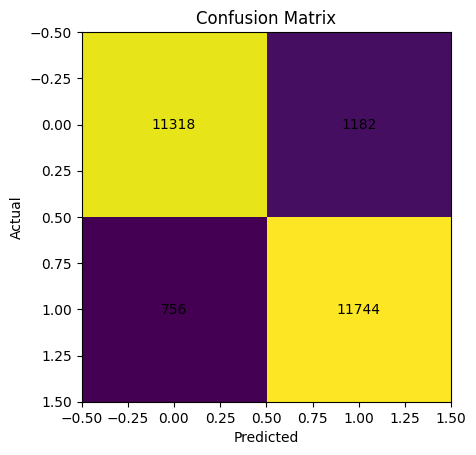

In [40]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true,y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
  for j in range(len(cm)):
    plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92     12500
           1       0.91      0.94      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000



In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.92248


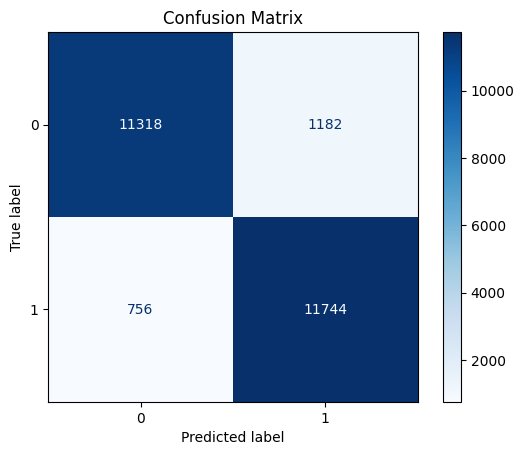

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix")
plt.show()

In [44]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="ashwini10521/finetuned_bert")

result = classifier("This movie was absolutely amazing!")
print(result)

config.json:   0%|          | 0.00/815 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[{'label': 'LABEL_1', 'score': 0.9925147891044617}]
